# RQ3 top-k

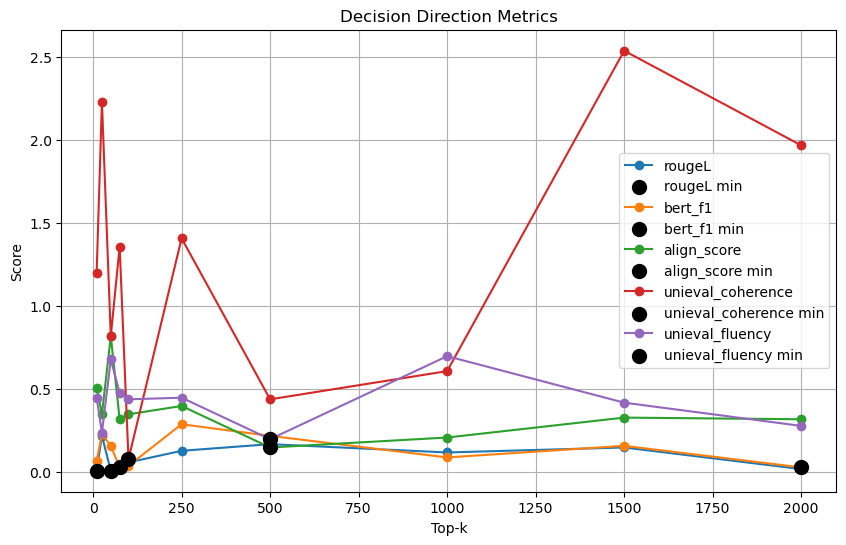

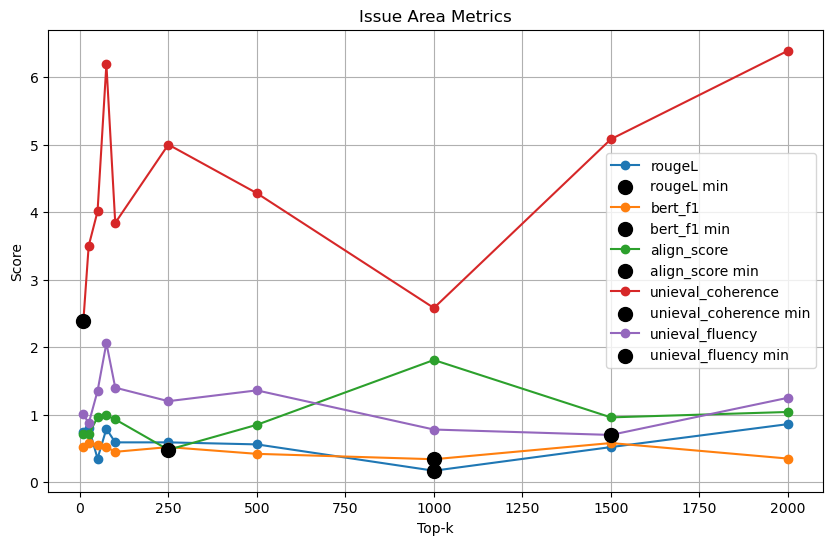

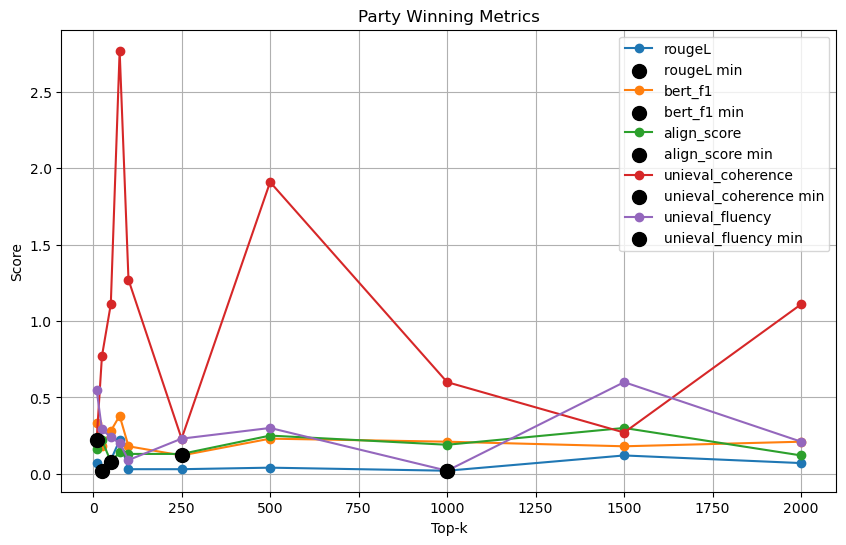

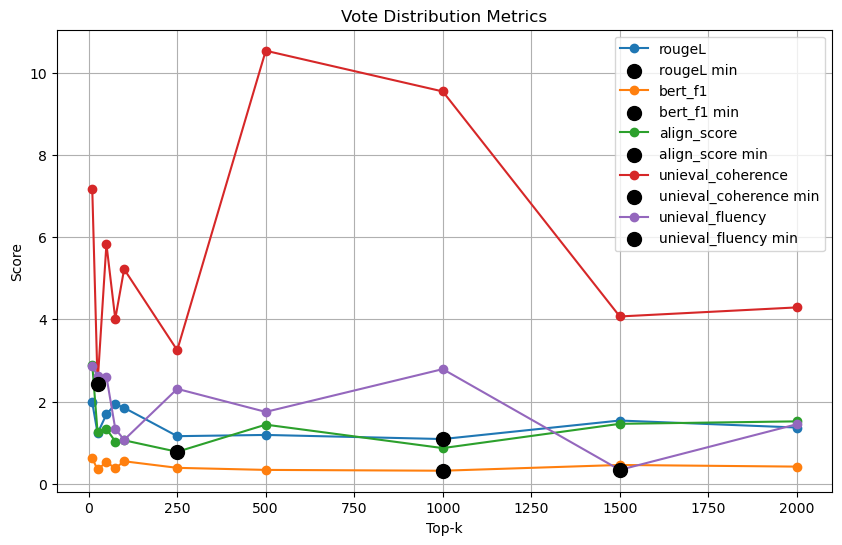

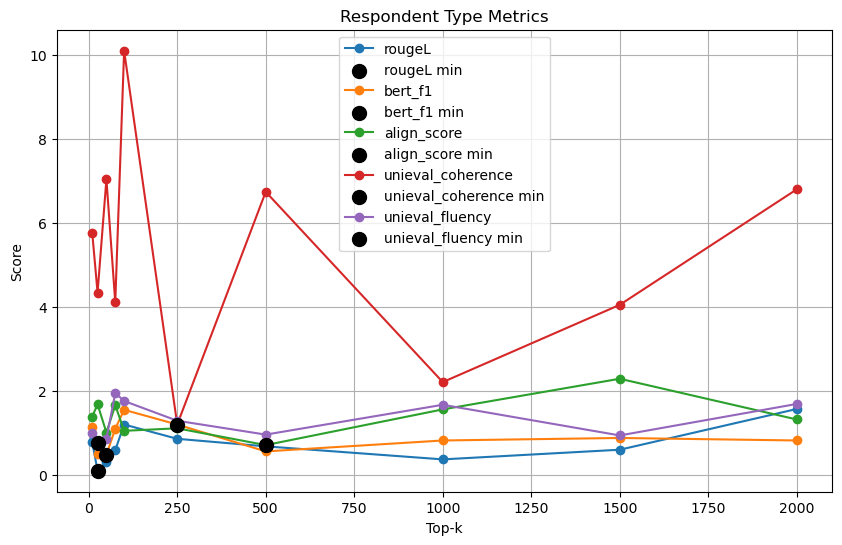

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
decision_direction_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [0.08, 0.03, 0.12, 0.05, 0.01, 0.08, 0.44, 0.14, 0.19, 0.28],
    # 'rouge2': [0.13, 0.02, 0.01, 0.04, 0.00, 0.04, 0.17, 0.08, 0.11, 0.03],
    'rougeL': [0.01, 0.22, 0.01, 0.04, 0.06, 0.13, 0.17, 0.12, 0.15, 0.02],
    'bert_f1': [0.07, 0.23, 0.16, 0.03, 0.04, 0.29, 0.22, 0.09, 0.16, 0.03],
    'align_score': [0.51, 0.35, 0.82, 0.32, 0.35, 0.40, 0.15, 0.21, 0.33, 0.32],
    'unieval_coherence': [1.20, 2.23, 0.82, 1.36, 0.08, 1.41, 0.44, 0.61, 2.54, 1.97],
    # 'unieval_consistency': [0.50, 0.25, 0.82, 0.21, 0.64, 0.63, 0.00, 0.30, 0.41, 0.17],
    'unieval_fluency': [0.45, 0.24, 0.68, 0.48, 0.44, 0.45, 0.20, 0.70, 0.42, 0.28]
}
issue_area_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [2.20, 1.63, 1.01, 2.12, 1.28, 0.77, 1.07, 1.33, 0.97, 2.03],
    # 'rouge2': [1.13, 1.29, 0.30, 0.98, 0.48, 0.28, 0.40, 0.30, 0.45, 1.14],
    'rougeL': [0.75, 0.81, 0.35, 0.79, 0.59, 0.59, 0.56, 0.17, 0.52, 0.86],
    'bert_f1': [0.52, 0.58, 0.55, 0.52, 0.45, 0.52, 0.42, 0.34, 0.58, 0.35],
    'align_score': [0.72, 0.71, 0.96, 0.99, 0.93, 0.48, 0.85, 1.81, 0.96, 1.04],
    'unieval_coherence': [2.39, 3.50, 4.01, 6.19, 3.84, 5.00, 4.28, 2.58, 5.08, 6.39],
    # 'unieval_consistency': [2.13, 1.63, 1.41, 1.26, 2.44, 2.22, 1.21, 2.49, 1.95, 2.52],
    'unieval_fluency': [1.01, 0.87, 1.35, 2.06, 1.40, 1.20, 1.36, 0.78, 0.70, 1.25]
}
party_winning_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [0.30, 0.10, 0.38, 0.65, 0.04, 0.07, 0.07, 0.25, 0.04, 0.27],
    # 'rouge2': [0.39, 0.43, 0.23, 0.25, 0.28, 0.24, 0.22, 0.30, 0.24, 0.29],
    'rougeL': [0.07, 0.02, 0.09, 0.22, 0.03, 0.03, 0.04, 0.02, 0.12, 0.07],
    'bert_f1': [0.33, 0.18, 0.28, 0.38, 0.18, 0.12, 0.23, 0.21, 0.18, 0.21],
    'align_score': [0.16, 0.22, 0.08, 0.14, 0.13, 0.13, 0.25, 0.19, 0.30, 0.12],
    'unieval_coherence': [0.22, 0.77, 1.11, 2.77, 1.27, 0.23, 1.91, 0.60, 0.27, 1.11],
    # 'unieval_consistency': [0.63, 0.20, 0.04, 0.41, 0.21, 0.02, 0.03, 0.38, 0.46, 0.45],
    'unieval_fluency': [0.55, 0.29, 0.24, 0.20, 0.09, 0.23, 0.30, 0.02, 0.60, 0.21]
}
vote_distribution_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [5.66, 3.57, 4.87, 4.13, 2.62, 1.43, 1.74, 3.30, 1.42, 1.94],
    # 'rouge2': [3.00, 2.02, 2.48, 2.29, 2.21, 0.83, 1.26, 1.34, 1.28, 1.69],
    'rougeL': [1.98, 1.23, 1.69, 1.94, 1.85, 1.16, 1.19, 1.09, 1.54, 1.37],
    'bert_f1': [0.62, 0.35, 0.53, 0.38, 0.55, 0.39, 0.34, 0.32, 0.46, 0.42],
    'align_score': [2.90, 1.25, 1.34, 1.03, 1.06, 0.78, 1.44, 0.87, 1.46, 1.52],
    'unieval_coherence': [7.17, 2.44, 5.83, 4.01, 5.22, 3.25, 10.53, 9.54, 4.07, 4.29],
    # 'unieval_consistency': [2.76, 2.28, 2.44, 0.86, 1.88, 0.87, 0.91, 1.71, 1.00, 1.11],
    'unieval_fluency': [2.87, 2.62, 2.61, 1.34, 1.07, 2.31, 1.75, 2.79, 0.34, 1.45]
}
respondent_type_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [1.10, 0.78, 0.45, 0.59, 0.96, 1.71, 1.15, 0.79, 0.93, 1.50],
    # 'rouge2': [0.69, 0.43, 0.50, 1.63, 0.82, 1.28, 0.25, 0.90, 0.36, 1.35],
    'rougeL': [0.78, 0.10, 0.30, 0.59, 1.20, 0.86, 0.68, 0.37, 0.60, 1.57],
    'bert_f1': [1.13, 0.50, 0.48, 1.10, 1.55, 1.20, 0.56, 0.82, 0.88, 0.82],
    'align_score': [1.39, 1.68, 1.01, 1.66, 1.05, 1.11, 0.71, 1.56, 2.29, 1.32],
    'unieval_coherence': [5.76, 4.34, 7.04, 4.11, 10.10, 1.20, 6.74, 2.21, 4.05, 6.80],
    # 'unieval_consistency': [3.45, 1.04, 1.59, 2.97, 0.71, 2.65, 2.05, 1.49, 1.06, 3.32],
    'unieval_fluency': [1.00, 0.77, 0.86, 1.95, 1.76, 1.29, 0.96, 1.67, 0.94, 1.69]
}

# Create DataFrames
decision_direction_df = pd.DataFrame(decision_direction_data)
issue_area_df = pd.DataFrame(issue_area_data)
party_winning_df = pd.DataFrame(party_winning_data)
vote_distribution_df = pd.DataFrame(vote_distribution_data)
respondent_type_df = pd.DataFrame(respondent_type_data)

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    for column in df.columns[1:]:
        y = df[column]
        plt.plot(df['top-k'], y, marker='o', label=column)
        
        # Highlight the minimum value
        min_value = y.min()
        min_indices = y[y == min_value].index
        plt.scatter(df['top-k'][min_indices], y[min_indices], color='black', s=100, zorder=5, label=f'{column} min')
    
    plt.title(title)
    plt.xlabel('Top-k')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot each section
plot_metrics(decision_direction_df, 'Decision Direction Metrics')
plot_metrics(issue_area_df, 'Issue Area Metrics')
plot_metrics(party_winning_df, 'Party Winning Metrics')
plot_metrics(vote_distribution_df, 'Vote Distribution Metrics')
plot_metrics(respondent_type_df, 'Respondent Type Metrics')


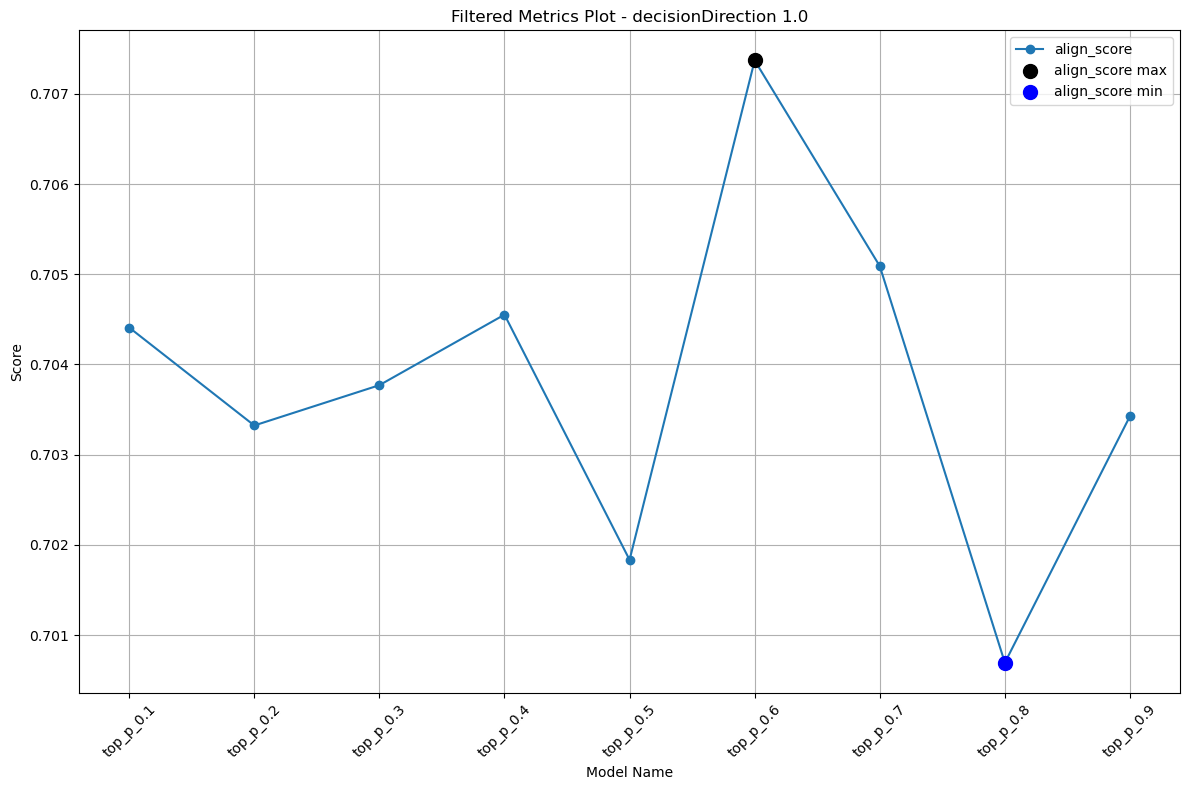

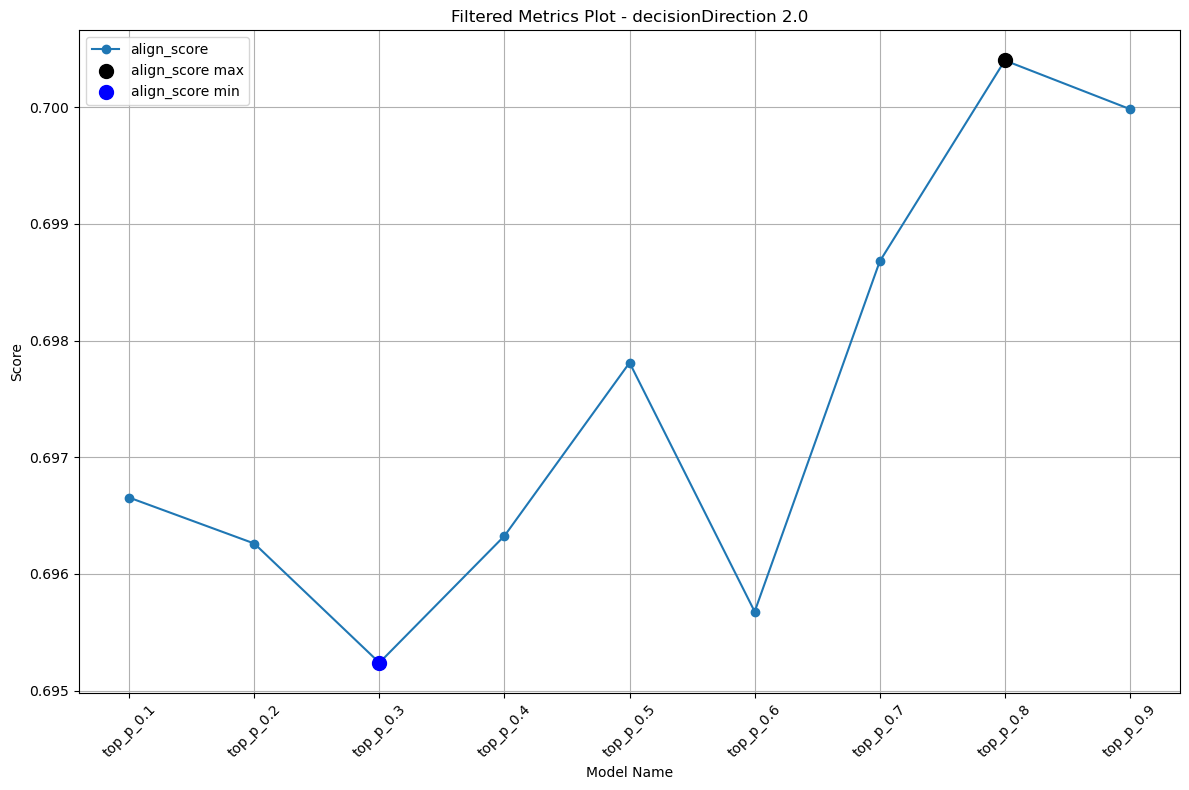

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def alphanumeric_sort_key(s):
    """Split the string into a list of strings and integers for sorting."""
    return [int(text) if text.isdigit() else text for text in re.split('(\d+)', s)]

def plot_metrics_from_csv(file_path, group_by_column, filter_substring, title_prefix):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    
    # Filter the DataFrame to include only rows where 'Model Name' contains the filter_substring
    filtered_df = df[df['Model Name'].str.contains(filter_substring)]
    
    # Drop the specified columns
    # 'rougeL',
    # 'rougeL',
    # 'rouge1',
    # 'rouge2',
    # 'align_score',
    # 'bert_f1',
    # 'unieval_relevance',
    # 'unieval_overall',
    # 'unieval_coherence',
    # 'unieval_fluency', 
    # 'unieval_consistency'
    columns_to_drop = [ 'bert_f1','rouge1', 'rouge2',  'rougeL','unieval_fluency', 'unieval_relevance', 'unieval_overall','unieval_coherence', 'unieval_consistency']
    filtered_df = filtered_df.drop(columns=columns_to_drop)
    
    # Sort the DataFrame by 'Model Name' using the custom sorting key
    sorted_df = filtered_df.sort_values(by='Model Name', key=lambda col: col.map(alphanumeric_sort_key))
    
    # Group the DataFrame by the specified column
    grouped = sorted_df.groupby(group_by_column)
    
    # Iterate over each group
    for group_name, group in grouped:
        plt.figure(figsize=(12, 8))
        for column in group.columns[2:]:  # Skip 'Model Name' and the group_by_column
            y = group[column]
            plt.plot(group['Model Name'], y, marker='o', label=column)
            
            # Highlight the maximum value
            max_value = y.max()
            max_indices = y[y == max_value].index
            plt.scatter(group['Model Name'][max_indices], y[max_indices], color='black', s=100, zorder=5, label=f'{column} max')

            # Highlight the minimum value
            min_value = y.min()
            min_indices = y[y == min_value].index
            plt.scatter(group['Model Name'][min_indices], y[min_indices], color='blue', s=100, zorder=5, label=f'{column} min')
        
        plt.title(f"{title_prefix} - {group_by_column} {group_name}")
        plt.xlabel('Model Name')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# decisionDirection
# issueArea
# partyWinning
# respondentType
# voteDistribution

# Example usage
plot_metrics_from_csv(
    '/home/mostah/workspace/fairness/scores/grouped average scores/decisionDirection.csv',
    'decisionDirection',
    'top_p',
    'Filtered Metrics Plot'
)


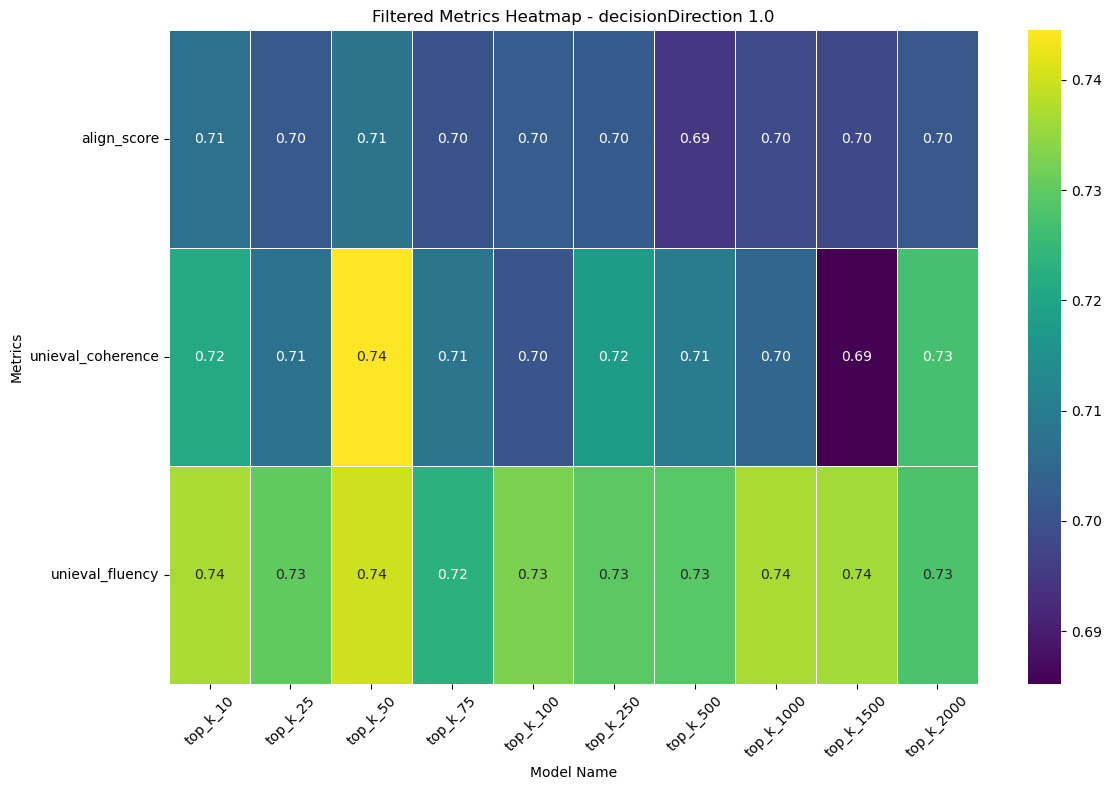

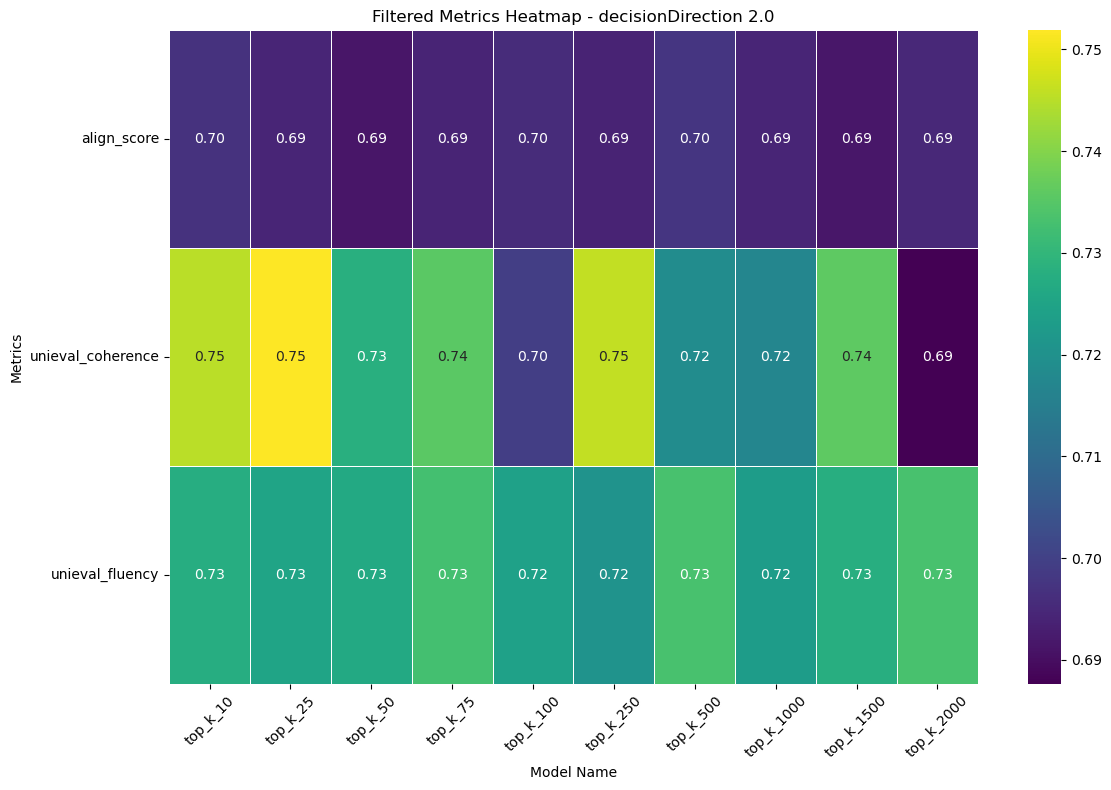

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def alphanumeric_sort_key(s):
    """Split the string into a list of strings and integers for sorting."""
    return [int(text) if text.isdigit() else text for text in re.split('(\d+)', s)]

def plot_heatmaps_from_csv(file_path, group_by_column, filter_substring, title_prefix):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    
    # Filter the DataFrame to include only rows where 'Model Name' contains the filter_substring
    filtered_df = df[df['Model Name'].str.contains(filter_substring)]
    
    # Drop the specified columns
    columns_to_drop = ['bert_f1','rougeL', 'rouge1', 'rouge2', 'unieval_relevance', 'unieval_overall', 'unieval_consistency']
    filtered_df = filtered_df.drop(columns=columns_to_drop)
    
    # Sort the DataFrame by 'Model Name' using the custom sorting key
    sorted_df = filtered_df.sort_values(by='Model Name', key=lambda col: col.map(alphanumeric_sort_key))
    
    # Group the DataFrame by the specified column
    grouped = sorted_df.groupby(group_by_column)
    
    # Iterate over each group
    for group_name, group in grouped:
        # Drop the group_by_column from the group DataFrame
        group = group.drop(columns=[group_by_column])
        
        # Set the index to 'Model Name' and transpose the DataFrame for heatmap
        heatmap_data = group.set_index('Model Name').T
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt=".2f", linewidths=0.5)
        
        plt.title(f"{title_prefix} - {group_by_column} {group_name}")
        plt.xlabel('Model Name')
        plt.ylabel('Metrics')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

# Example usage
plot_heatmaps_from_csv(
    '/home/mostah/workspace/fairness/scores/grouped average scores/decisionDirection.csv',
    'decisionDirection',
    'top_k',
    'Filtered Metrics Heatmap'
)
